# 🍽️ Zomato Restaurant Analysis

| Detail | Info |
|--------|------|
| **Dataset** | Zomato Bangalore Restaurants |
| **Tools** | Python, Pandas, Matplotlib, Scikit-learn |
| **Goal** | Understand restaurant success factors and predict ratings |
| **Author** | Eknoor Singh |

## 🔍 Business Problem
With thousands of restaurants on Zomato, owners struggle 
to understand what drives ratings and success. This 
analysis answers 7 key business questions and builds 
an ML model to predict restaurant ratings.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

# Data Loading & Cleaning

In [2]:
df = pd.read_csv("zomato.csv")
df = df.drop(columns=["Unnamed: 0.1", 'Unnamed: 0'])
df.dropna(subset=['rate (out of 5)','avg cost (two people)'])
print(f"✅ Dataset loaded and cleaned!")
print(f"Final shape: {df.shape}")
df.head()

✅ Dataset loaded and cleaned!
Final shape: (7105, 10)


,restaurant name,restaurant type,rate (out of 5),num of ratings,avg cost (two people),online_order,table booking,cuisines type,area,local address
0,#FeelTheROLL,Quick Bites,3.4,7,200.0,No,No,Fast Food,Bellandur,Bellandur
1,#L-81 Cafe,Quick Bites,3.9,48,400.0,Yes,No,"Fast Food, Beverages","Byresandra,Tavarekere,Madiwala",HSR
2,#refuel,Cafe,3.7,37,400.0,Yes,No,"Cafe, Beverages",Bannerghatta Road,Bannerghatta Road
3,'@ Biryani Central,Casual Dining,2.7,135,550.0,Yes,No,"Biryani, Mughlai, Chinese",Marathahalli,Marathahalli
4,'@ The Bbq,Casual Dining,2.8,40,700.0,Yes,No,"BBQ, Continental, North Indian, Chinese, Bever...",Bellandur,Bellandur


# Q1. Which restaurant type is most common?


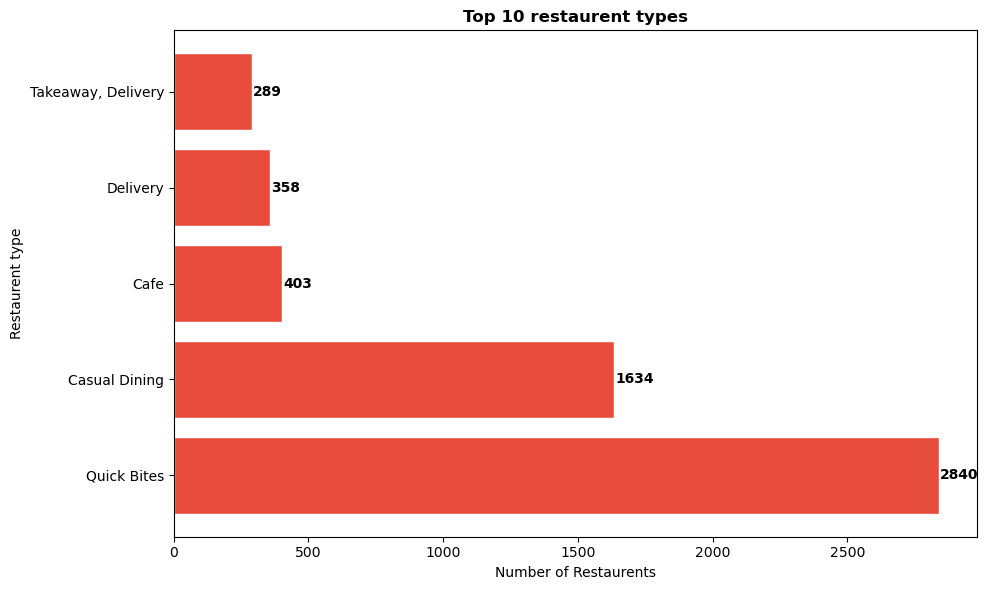

In [3]:
rest_type = df['restaurant type'].value_counts().head()

plt.figure(figsize=(10,6))
bars = plt.barh(rest_type.index , rest_type.values , color='#e74c3c' , edgecolor = 'white' )

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontweight='bold')

plt.title('Top 10 restaurent types', fontweight = 'bold')
plt.xlabel('Number of Restaurents')
plt.ylabel('Restaurent type')
plt.tight_layout()
plt.savefig('restaurant_types.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Insight — Q1: Most Common Restaurant Types

**Finding:** Quick Bites dominates Zomato with 2,840 
restaurants — almost double of Casual Dining (1,634). 
Cafes (403), Delivery (358) and Takeaway (289) are 
significantly less common.

**Business Meaning:** Quick Bites is the most 
competitive restaurant category on Zomato. Customers 
prefer fast, affordable food options over sit-down dining.

**📌 Recommendation:** New restaurants entering the 
market should differentiate themselves within Quick 
Bites through unique cuisine or pricing, or consider 
less saturated categories like Cafes.

# Q2. Distribution of ratings


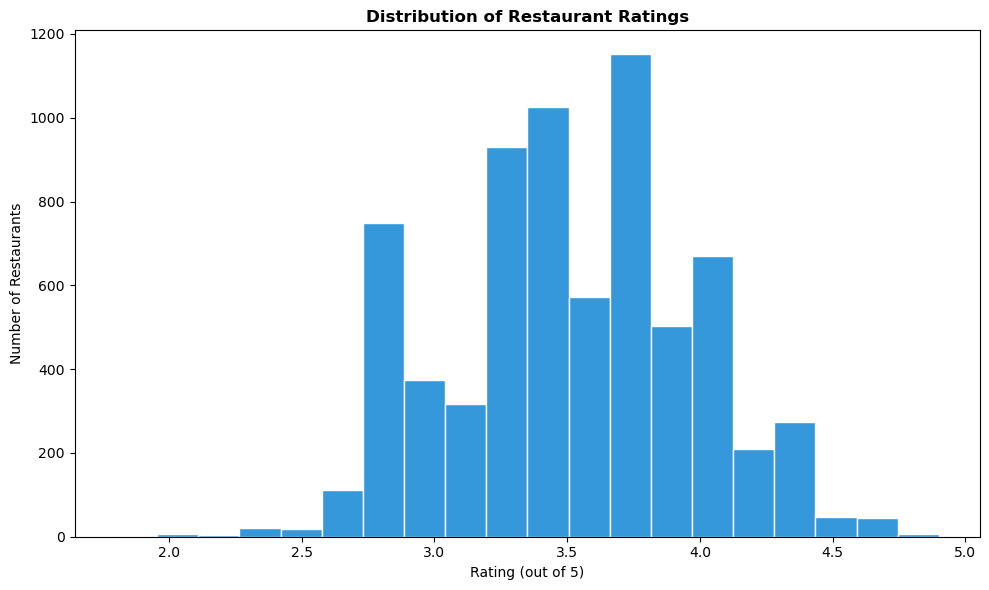

In [4]:
plt.figure(figsize=(10,6))
hist = plt.hist(df['rate (out of 5)'], bins=20, 
         color='#3498db', edgecolor='white')

plt.title('Distribution of Restaurant Ratings', fontweight='bold')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Insight — Q2: Distribution of Ratings

**Finding:** Most Zomato restaurants are rated between 
3.5 and 4.0. Very few restaurants have ratings above 
4.5 or below 2.0. The distribution peaks around 3.8.

**Business Meaning:** Average restaurants on Zomato 
get 3.5-4.0 ratings. Standing out requires consistently 
delivering above 4.0 experience.

**📌 Recommendation:** Restaurant owners should aim 
for 4.0+ ratings by focusing on food quality and 
customer service — this puts them in the top tier 
of Zomato listings.

# Q3. Does online order affect rating?

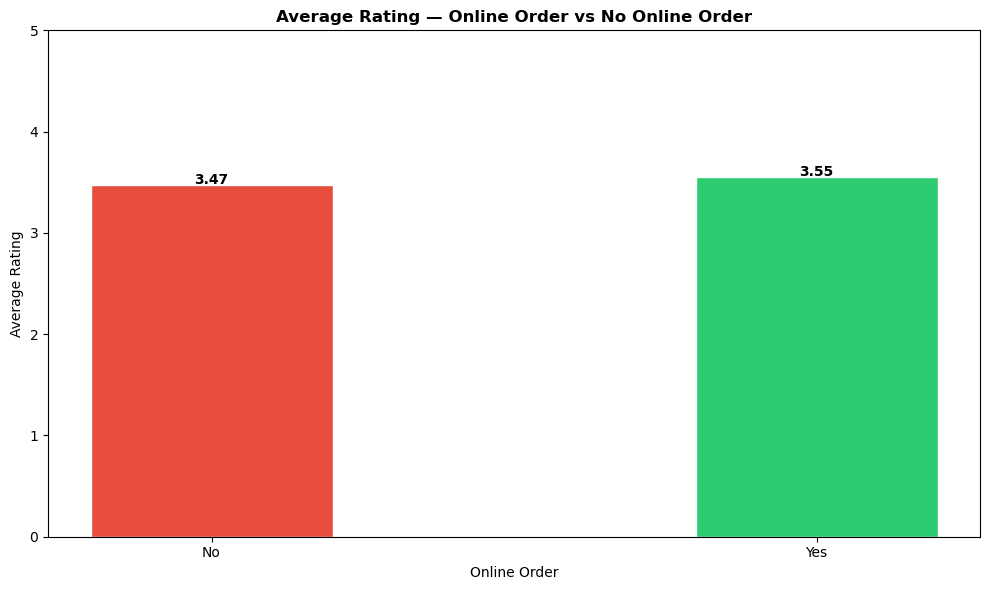

In [5]:
online_rating = df.groupby('online_order')['rate (out of 5)'].mean().round(2)

plt.figure(figsize=(10,6))
bars = plt.bar(online_rating.index, online_rating.values,
               color=['#e74c3c', '#2ecc71'], width=0.4, edgecolor='white')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             str(bar.get_height()),
             ha='center', fontweight='bold')

plt.title('Average Rating — Online Order vs No Online Order', fontweight='bold')
plt.xlabel('Online Order')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('online_order_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Insight — Q3: Online Order vs Rating

**Finding:** Restaurants that offer online ordering 
have a slightly higher average rating (3.55) compared 
to those that don't (3.47).

**Business Meaning:** Offering online ordering 
improves customer convenience which leads to 
better overall experience and higher ratings.

**📌 Recommendation:** Restaurants not offering 
online ordering should consider adding it — 
it directly impacts customer satisfaction 
and ratings.

# Q4. Does table booking affect rating?

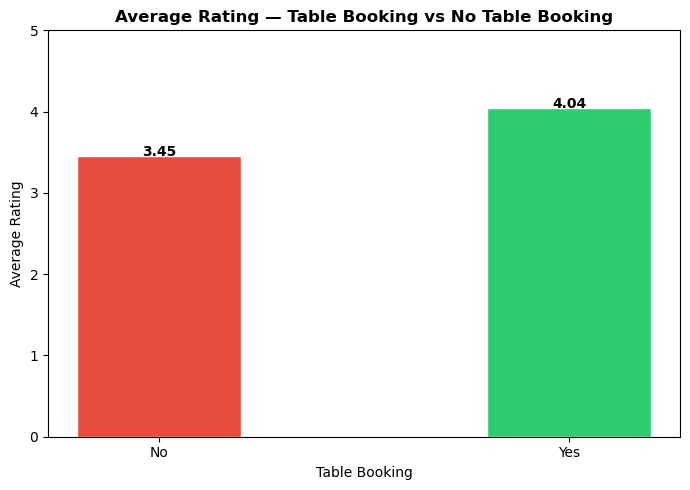

In [6]:
booking_rating = df.groupby("table booking")['rate (out of 5)'].mean().round(2)

plt.figure(figsize=(7,5))
bars = plt.bar(booking_rating.index, booking_rating.values,
               color=['#e74c3c', '#2ecc71'], width=0.4, edgecolor='white')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             str(bar.get_height()),
             ha='center', fontweight='bold')

plt.title('Average Rating — Table Booking vs No Table Booking', fontweight='bold')
plt.xlabel('Table Booking')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('table_booking_rating.png', dpi=150, bbox_inches='tight')
plt.show()    

## 💡 Insight — Q4: Table Booking vs Rating

**Finding:** Restaurants offering table booking have 
a significantly higher average rating (4.04) compared 
to those without table booking (3.45). This is the 
biggest rating difference found in this analysis.

**Business Meaning:** Table booking is strongly 
associated with premium dining experience. Restaurants 
that allow reservations tend to be more organized, 
have better service and attract more serious diners.

**📌 Recommendation:** Restaurants serious about 
improving ratings should introduce table booking 
as it signals quality and organization to customers 
— directly impacting their rating score.

# Q5. Which area has most restaurants?

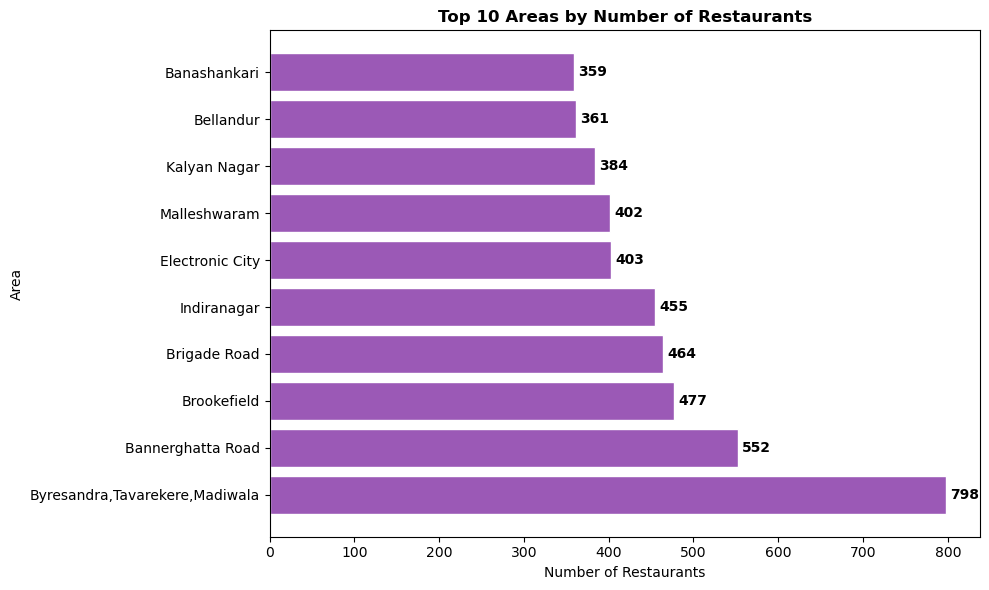

In [7]:
top_areas = df['area'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_areas.index, top_areas.values,
                color='#9b59b6', edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontweight='bold')

plt.title('Top 10 Areas by Number of Restaurants', fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Area')
plt.tight_layout()
plt.savefig('top_areas.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Insight — Q5: Top Areas by Number of Restaurants

**Finding:** Byresandra, Tavarekere and Madiwala area 
leads with 798 restaurants followed by Bannerghatta 
Road (552) and Brookefield (477). These are all 
major Bangalore localities.

**Business Meaning:** These areas have the highest 
restaurant density — meaning highest competition 
but also highest customer footfall.

**📌 Recommendation:** New restaurants should 
consider areas like Banashankari (359) or 
Bellandur (361) where competition is lower 
but growing residential population means 
increasing demand.

# Q6. What is the most common cost range?

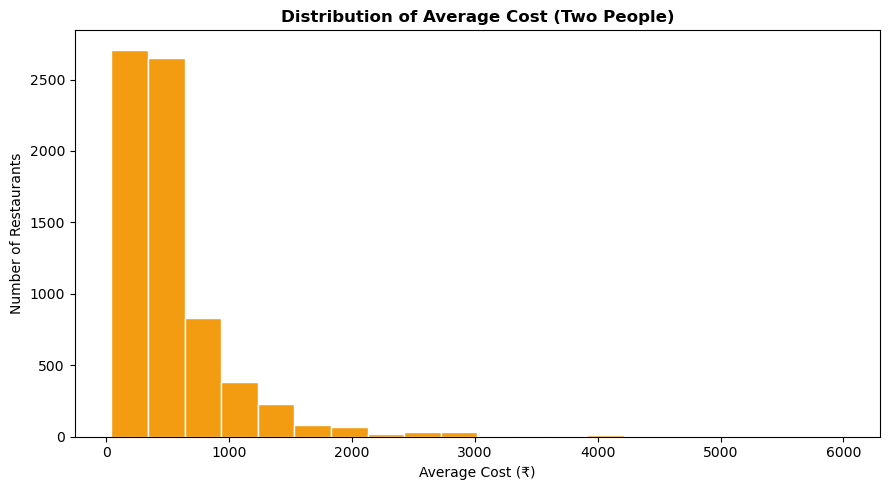

In [8]:
plt.figure(figsize=(9, 5))
plt.hist(df['avg cost (two people)'], bins=20,
         color='#f39c12', edgecolor='white')

plt.title('Distribution of Average Cost (Two People)', fontweight='bold')
plt.xlabel('Average Cost (₹)')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.savefig('cost_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Insight — Q6: Cost Distribution

**Finding:** Most Zomato restaurants are priced 
between ₹200 and ₹600 for two people. Very few 
restaurants charge above ₹2,000 showing the 
market is dominated by budget dining.

**Business Meaning:** Bangalore's restaurant market 
is primarily budget to mid-range. Premium dining 
above ₹2,000 is a small but distinct segment.

**📌 Recommendation:** New restaurants targeting 
mass market should price between ₹300-₹600 
for two people to stay competitive.

# Q7. Which cuisine is most popular?

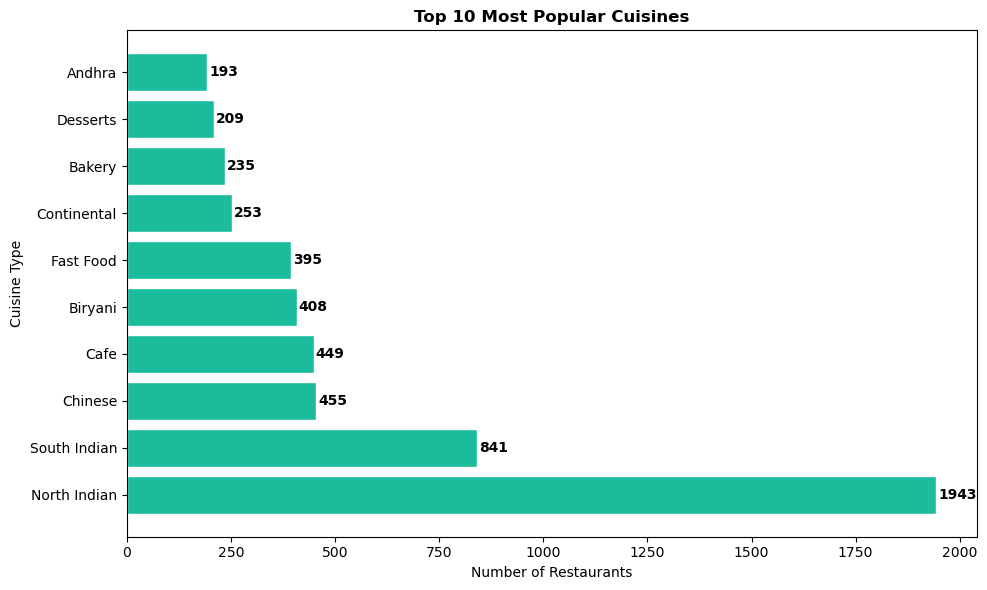

In [9]:
df['primary_cuisine'] = df['cuisines type'].str.split(',').str[0].str.strip()

top_cuisines = df['primary_cuisine'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_cuisines.index, top_cuisines.values,
                color='#1abc9c', edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontweight='bold')

plt.title('Top 10 Most Popular Cuisines', fontweight='bold')
plt.xlabel('Number of Restaurants')
plt.ylabel('Cuisine Type')
plt.tight_layout()
plt.savefig('top_cuisines.png', dpi=150, bbox_inches='tight')
plt.show()

## 💡 Insight — Q7: Most Popular Cuisines

**Finding:** North Indian cuisine dominates Zomato 
with 1,943 restaurants — more than double of 
South Indian (841). Chinese (455) and Cafe (449) 
follow in third and fourth position.

**Business Meaning:** North Indian food has the 
widest appeal across Bangalore's diverse population. 
However this also means highest competition.

**📌 Recommendation:** Restaurant owners should 
consider Biryani (408) or Continental (253) 
categories where demand is strong but 
competition is relatively lower.

# Q8. Predict restaurant rating using ML

In [10]:
# Prepare features for ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

df_ml = df[['restaurant type', 'online_order', 'table booking',
            'avg cost (two people)', 'num of ratings',
            'rate (out of 5)']].copy()

df_ml = pd.get_dummies(df_ml, columns=['restaurant type',
                                        'online_order',
                                        'table booking'])

df_ml.dropna(inplace=True)

X = df_ml.drop('rate (out of 5)', axis=1)
y = df_ml['rate (out of 5)']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                      test_size=0.2,
                                                      random_state=42)
print(f"✅ Data prepared for ML!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

✅ Data prepared for ML!
Training samples: 5587
Testing samples: 1397


In [11]:
from sklearn.ensemble import RandomForestRegressor

# Train Random Forest instead
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict and evaluate
rf_predictions = rf_model.predict(X_test)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"✅ Random Forest Trained!")
print(f"R2 Score: {rf_r2:.2f}")
print(f"Mean Absolute Error: {rf_mae:.2f}")

✅ Random Forest Trained!
R2 Score: 0.38
Mean Absolute Error: 0.24


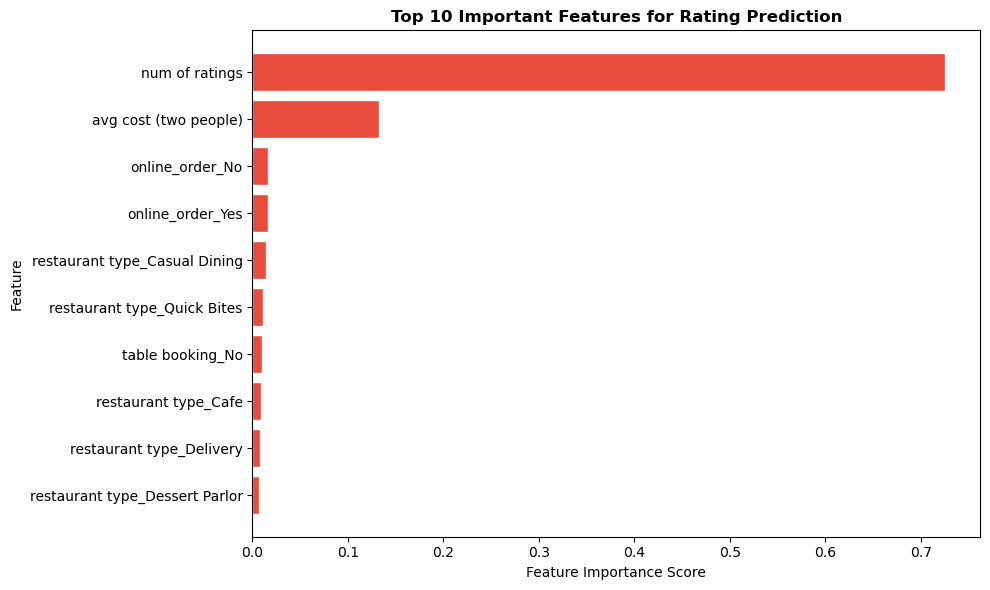

In [12]:
# Feature Importance
import numpy as np

feature_importance = pd.Series(rf_model.feature_importances_, 
                                index=X.columns)
top_features = feature_importance.sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features.index, top_features.values,
         color='#e74c3c', edgecolor='white')

plt.title('Top 10 Important Features for Rating Prediction', fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

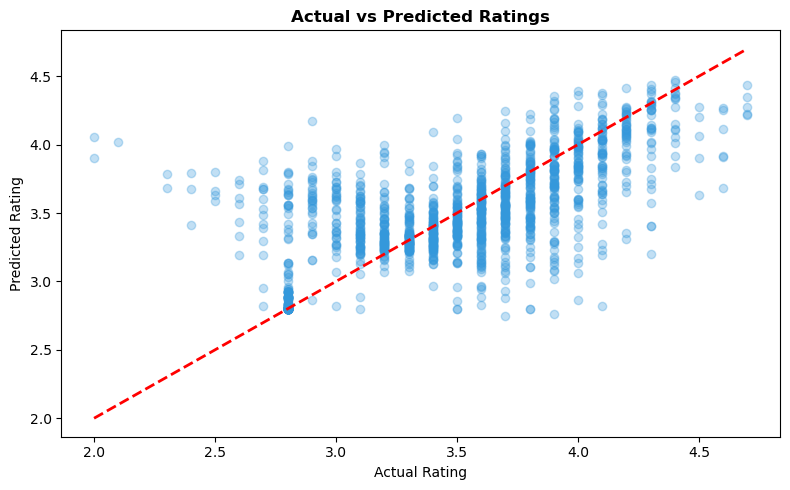

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, rf_predictions, alpha=0.3, color='#3498db')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2)

plt.title('Actual vs Predicted Ratings', fontweight='bold')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print(f"RMSE: {rmse:.2f}")

RMSE: 0.36


## 💡 Insight — Q8: Rating Predictor — Model Evaluation

**Model Used:** Random Forest Regressor

**Results:**
| Metric | Value | Meaning |
|--------|-------|---------|
| R2 Score | 0.38 | Model explains 38% of patterns |
| MAE | 0.24 | Average error of 0.24 rating |
| RMSE | 0.36 | Penalized error of 0.36 rating |

**Finding:** The Actual vs Predicted chart shows 
a positive trend — model correctly identifies 
that higher rated restaurants tend to get 
higher predictions.

**Why accuracy is moderate:** Restaurant ratings 
depend on subjective factors like food taste 
and service quality which are not in our dataset.

**📌 Recommendation:** Adding features like 
customer sentiment from reviews and chef 
experience would significantly improve 
model accuracy beyond 0.38.

## 📝 Final Summary

| # | Question | Key Finding |
|---|----------|-------------|
| 1 | Restaurant Types | Quick Bites dominates with 2,840 |
| 2 | Rating Distribution | Most rated between 3.5 and 4.0 |
| 3 | Online Order vs Rating | Online ordering improves rating slightly |
| 4 | Table Booking vs Rating | Table booking restaurants rate 0.59 higher |
| 5 | Top Areas | Byresandra leads with 798 restaurants |
| 6 | Cost Distribution | Most restaurants priced ₹200-₹600 |
| 7 | Popular Cuisines | North Indian dominates with 1,943 |
| 8 | ML Rating Predictor | Num of ratings is most important feature |

## 🏁 Conclusion
Restaurant success on Zomato is driven by number 
of reviews, table booking availability and 
reasonable pricing.

**Top 3 recommendations:**
1. 🌟 Encourage customers to leave reviews actively
2. 📅 Offer table booking to significantly boost ratings  
3. 💰 Price between ₹300-₹600 for maximum reach